# **Loading The Dataset**

In [22]:
import kagglehub

path = kagglehub.dataset_download("muqaddasejaz/netflix-movies-and-tv-shows-dataset")
path = path + "/netflix_titles.csv"
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'netflix-movies-and-tv-shows-dataset' dataset.
Path to dataset files: /kaggle/input/netflix-movies-and-tv-shows-dataset/netflix_titles.csv


# **Importing The Dataset**

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# **Importing Dataset**

In [24]:
df = pd.read_csv(path)

In [25]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [26]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [27]:
df.describe(include='object')

,show_id,type,title,director,cast,country,date_added,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,17,220,514,8775
top,s8807,Movie,Zubaan,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,3207,1793,362,4


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


# **Identifying Null Values**

In [29]:
print(df.isnull().sum())

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


**Extracted Duration for Movies**

In [30]:
movies['duration_min'] = pd.to_numeric(
    movies['duration'].str.extract(r'(\d+)')[0],
    errors='coerce'
)

movies = movies.dropna(subset=['duration_min'])
movies['duration_min'] = movies['duration_min'].astype(int)

**Extracted number of seasons for shows**

In [31]:
shows['num_seasons'] = pd.to_numeric(
    shows['duration'].str.extract(r'(\d+)')[0],
    errors='coerce'
)

shows = shows.dropna(subset=['num_seasons'])
shows['num_seasons'] = shows['num_seasons'].astype(int)

**Plot for Movie Duration / Number Of Movies**

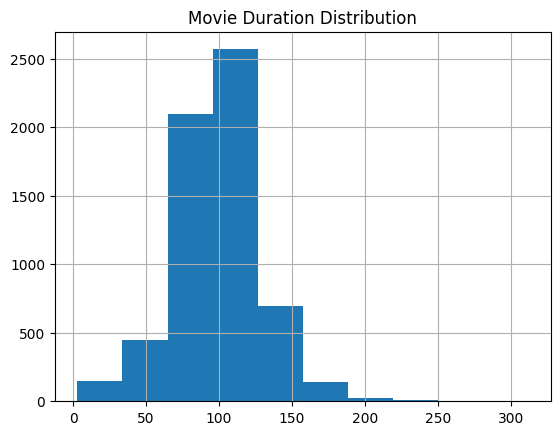

In [32]:
movies['duration_min'].hist()
plt.title("Movie Duration Distribution")
plt.xlabel("Minutes")
plt.ylabel("Count")
plt.show()

**Number of Season Distribuition for shows**

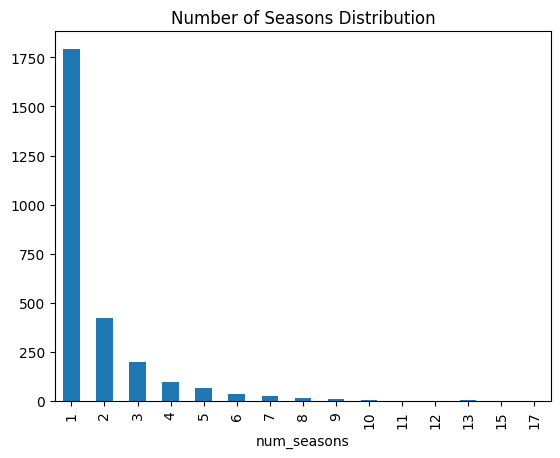

In [33]:
shows['num_seasons'].value_counts().sort_index().plot(kind='bar')
plt.title("Number of Seasons Distribution")
plt.xlabel("Seasons")
plt.ylabel("Count")
plt.show()

**Checking correlation with duration and release year**

In [35]:
movie_duration_release_year = movies[['release_year', 'duration_min']]
print(movie_duration_release_year.corr())

              release_year  duration_min
release_year      1.000000     -0.206285
duration_min     -0.206285      1.000000


In [37]:
show_duration_release_year = shows[['release_year', 'num_seasons']]
print(show_duration_release_year.corr())

              release_year  num_seasons
release_year      1.000000    -0.090194
num_seasons      -0.090194     1.000000


Correlation analysis was performed between release year and content duration. For movies, a weak negative correlation (-0.206) was observed, suggesting that newer movies tend to be slightly shorter on average. For TV shows, the correlation between release year and number of seasons was very weak (-0.090), indicating almost no relationship between the two variables. Overall, release year is not a strong predictor of content duration in the Netflix dataset.

# **Plot of trend for Number of releases per Year**

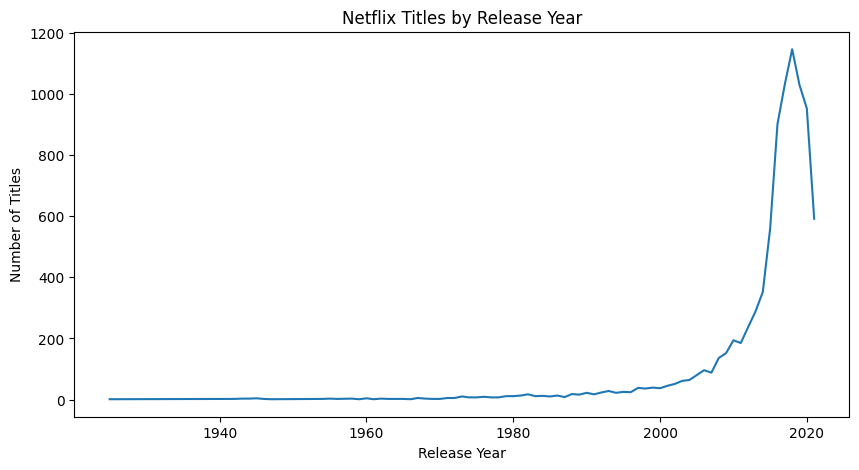

In [38]:
titles_per_year = df['release_year'].value_counts().sort_index()
titles_per_year.plot(figsize=(10,5))
plt.title("Netflix Titles by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.show()

# **Number of TV shows vs Movies**

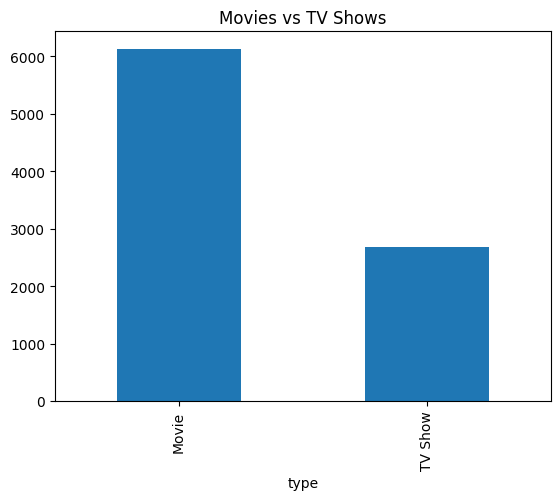

In [39]:
df['type'].value_counts().plot(kind='bar')
plt.title("Movies vs TV Shows")
plt.show()

# **Most Common Ratings**

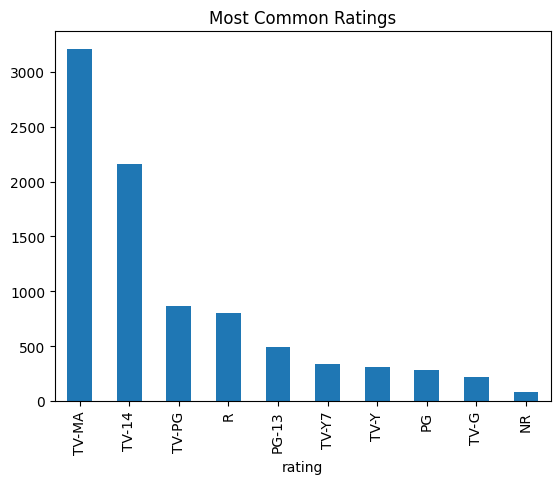

In [40]:
df['rating'].value_counts().head(10).plot(kind='bar')

plt.title("Most Common Ratings")
plt.show()

# **Plot of Countries vs Number of Releases**

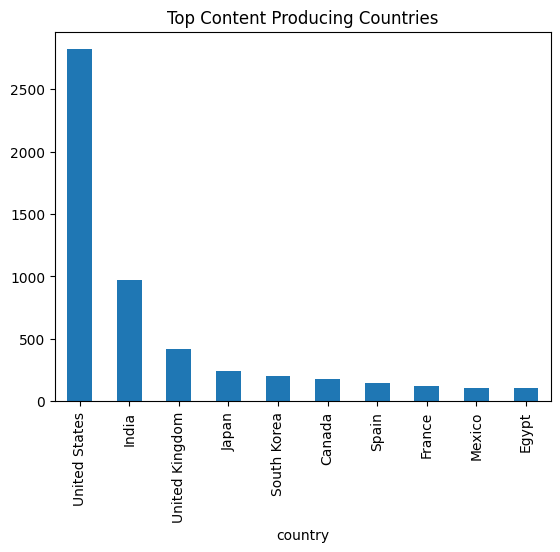

In [41]:
df['country'].value_counts().head(10).plot(kind='bar')

plt.title("Top Content Producing Countries")
plt.show()